## Import All Required Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Scikit-learn for machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings('ignore')

## Load Your Dataset

In [3]:
df = pd.read_csv("Maize dataset.csv")
df.head()
print(df.shape)
print(df.columns.tolist())

(166824, 10)
['Region', 'Soil_Type', 'Crop', 'Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used', 'Irrigation_Used', 'Weather_Condition', 'Days_to_Harvest', 'Yield_tons_per_hectare']


In [18]:
df

,Soil_Type,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Yield_tons_per_hectare,Profit_Category
0,Clay,888.207630,39.945509,True,False,76,7.173037,High
1,Chalky,170.814456,29.116377,False,True,133,2.332255,Low
2,Silt,259.418125,17.261892,False,False,110,2.338541,Low
3,Silt,609.798764,38.265851,True,False,127,5.113588,Medium
4,Clay,599.875493,19.909292,True,False,63,4.696425,Medium
...,...,...,...,...,...,...,...,...
166819,Clay,983.886166,16.336806,True,False,136,6.316806,High
166820,Loam,937.141579,37.541292,False,True,129,6.813543,High
166821,Silt,558.508670,19.505014,False,False,92,3.624284,Low
166822,Loam,196.392138,30.261504,True,True,107,3.689114,Low


## Data Exploration

In [4]:
print("=== Data Info ===")
df.info()

print("\n=== Statistical Summary ===")
display(df.describe())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Duplicate Rows ===")
print(f"Total duplicates: {df.duplicated().sum()}")

cat_cols = ['Region', 'Soil_Type', 'Crop', 'Irrigation', 'Fertilizer', 'Weather']
for col in cat_cols:
    if col in df.columns:
        print(f"\n{col} unique values: {df[col].unique()}")

=== Data Info ===
<class 'pandas.DataFrame'>
RangeIndex: 166824 entries, 0 to 166823
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Region                  166824 non-null  str    
 1   Soil_Type               166824 non-null  str    
 2   Crop                    166824 non-null  str    
 3   Rainfall_mm             166824 non-null  float64
 4   Temperature_Celsius     166824 non-null  float64
 5   Fertilizer_Used         166824 non-null  bool   
 6   Irrigation_Used         166824 non-null  bool   
 7   Weather_Condition       166824 non-null  str    
 8   Days_to_Harvest         166824 non-null  int64  
 9   Yield_tons_per_hectare  166824 non-null  float64
dtypes: bool(2), float64(3), int64(1), str(4)
memory usage: 10.5 MB

=== Statistical Summary ===


,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,166824.000000,166824.000000,166824.000000,166824.000000
mean,549.195094,27.477555,104.538927,4.641387
std,259.904451,7.217551,25.952050,1.696023
min,100.006823,15.000196,60.000000,-0.875193
25%,323.726771,21.223494,82.000000,3.409851
50%,549.672583,27.471440,105.000000,4.642647
75%,774.026381,33.709365,127.000000,5.870040
max,999.998098,39.999933,149.000000,9.952983



=== Missing Values ===
Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64

=== Duplicate Rows ===
Total duplicates: 0

Region unique values: <StringArray>
['South', 'East', 'North', 'West']
Length: 4, dtype: str

Soil_Type unique values: <StringArray>
['Clay', 'Chalky', 'Silt', 'Loam', 'Sandy', 'Peaty']
Length: 6, dtype: str

Crop unique values: <StringArray>
['Maize']
Length: 1, dtype: str


## Perfect Data Cleaning

In [5]:
columns_to_drop = ['Crop','Weather_Condition','Region']
df = df.drop(columns=columns_to_drop, errors='ignore')

num_cols = ['Rainfall_mm', 'Temperature_C', 'Area_hectares', 'Yield_tons_per_hectare']
cat_cols = ['Region', 'Soil_Type', 'Irrigation', 'Fertilizer', 'Weather']

for col in num_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

df = df.drop_duplicates().reset_index(drop=True)

bool_cols = ['Irrigation', 'Fertilizer']
for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].astype(int)  


for col in num_cols:
    if col in df.columns:
        lower = df[col].quantile(0.01)
        upper = df[col].quantile(0.99)
        df[col] = np.clip(df[col], lower, upper)

print("✅ Perfect data cleaning completed!")
print(f"Final shape after cleaning: {df.shape}")
df.head()

✅ Perfect data cleaning completed!
Final shape after cleaning: (166824, 7)


,Soil_Type,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Yield_tons_per_hectare
0,Clay,888.207630,39.945509,True,False,76,7.173037
1,Chalky,170.814456,29.116377,False,True,133,2.332255
2,Silt,259.418125,17.261892,False,False,110,2.338541
3,Silt,609.798764,38.265851,True,False,127,5.113588
4,Clay,599.875493,19.909292,True,False,63,4.696425


## Feature Engineering

In [6]:
df['Profit_Category'] = pd.qcut(df['Yield_tons_per_hectare'], q=3, labels=['Low', 'Medium', 'High'])

print("✅ Target created (balanced classes)")
print(df['Profit_Category'].value_counts())

✅ Target created (balanced classes)
Profit_Category
Low       55608
Medium    55608
High      55608
Name: count, dtype: int64


## EDA Visualizations

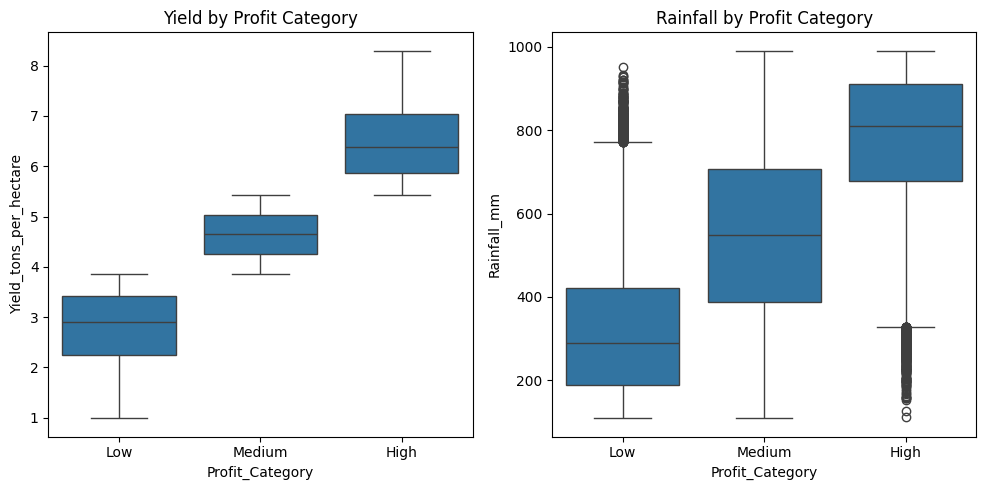

In [7]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(x='Profit_Category', y='Yield_tons_per_hectare', data=df)
plt.title('Yield by Profit Category')

plt.subplot(1, 3, 2)
sns.boxplot(x='Profit_Category', y='Rainfall_mm', data=df)
plt.title('Rainfall by Profit Category')

plt.tight_layout()
plt.show()

## Prepare Features (X) and Target (y)

In [8]:
X = df.drop(columns=['Yield_tons_per_hectare', 'Profit_Category'])
y = df['Profit_Category']

print(f"Features shape: {X.shape}")
print("Features used:", list(X.columns))

Features shape: (166824, 6)
Features used: ['Soil_Type', 'Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used', 'Irrigation_Used', 'Days_to_Harvest']


## Encode Categorical Features

In [17]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns (object dtype)
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Categorical columns: {categorical_cols}")

# Encode categorical columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print("✅ Categorical encoding completed!")
print(X.head(10))

Categorical columns: []
✅ Categorical encoding completed!
   Soil_Type  Rainfall_mm  Temperature_Celsius  Fertilizer_Used  \
0          1   888.207630            39.945509             True   
1          0   170.814456            29.116377            False   
2          5   259.418125            17.261892            False   
3          5   609.798764            38.265851             True   
4          1   599.875493            19.909292             True   
5          2   695.208413            23.736285             True   
6          1   318.013010            37.382965            False   
7          4   224.068712            38.186683            False   
8          1   348.131017            37.174675             True   
9          4   191.118084            19.549062             True   

   Irrigation_Used  Days_to_Harvest  
0            False               76  
1             True              133  
2            False              110  
3            False              127  
4            F

## Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"Feature types after encoding:")
print(X_train.dtypes)

Training samples: 133459
Testing samples: 33365
Feature types after encoding:
Soil_Type                int64
Rainfall_mm            float64
Temperature_Celsius    float64
Fertilizer_Used           bool
Irrigation_Used           bool
Days_to_Harvest          int64
dtype: object


## Train the model

In [16]:
model_dt = DecisionTreeClassifier(random_state=42, max_depth=10)
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15)

print("Training Decision Tree and Random Forest... ⏳")
model_dt.fit(X_train, y_train)
model_rf.fit(X_train, y_train)
print("✅ Both models trained successfully!")

# Predictions on both train and test sets
y_pred_dt_train = model_dt.predict(X_train)
y_pred_dt_test = model_dt.predict(X_test)

y_pred_rf_train = model_rf.predict(X_train)
y_pred_rf_test = model_rf.predict(X_test)


print("DECISION TREE RESULTS")
print(f"Training Accuracy: {accuracy_score(y_train, y_pred_dt_train):.4f}")
print(f"Testing Accuracy:  {accuracy_score(y_test, y_pred_dt_test):.4f}")

print("RANDOM FOREST RESULTS")
print(f"Training Accuracy: {accuracy_score(y_train, y_pred_rf_train):.4f}")
print(f"Testing Accuracy:  {accuracy_score(y_test, y_pred_rf_test):.4f}")

Training Decision Tree and Random Forest... ⏳
✅ Both models trained successfully!
DECISION TREE RESULTS
Training Accuracy: 0.8485
Testing Accuracy:  0.8318
RANDOM FOREST RESULTS
Training Accuracy: 0.8996
Testing Accuracy:  0.8368


## Model Evaluation Visualizations

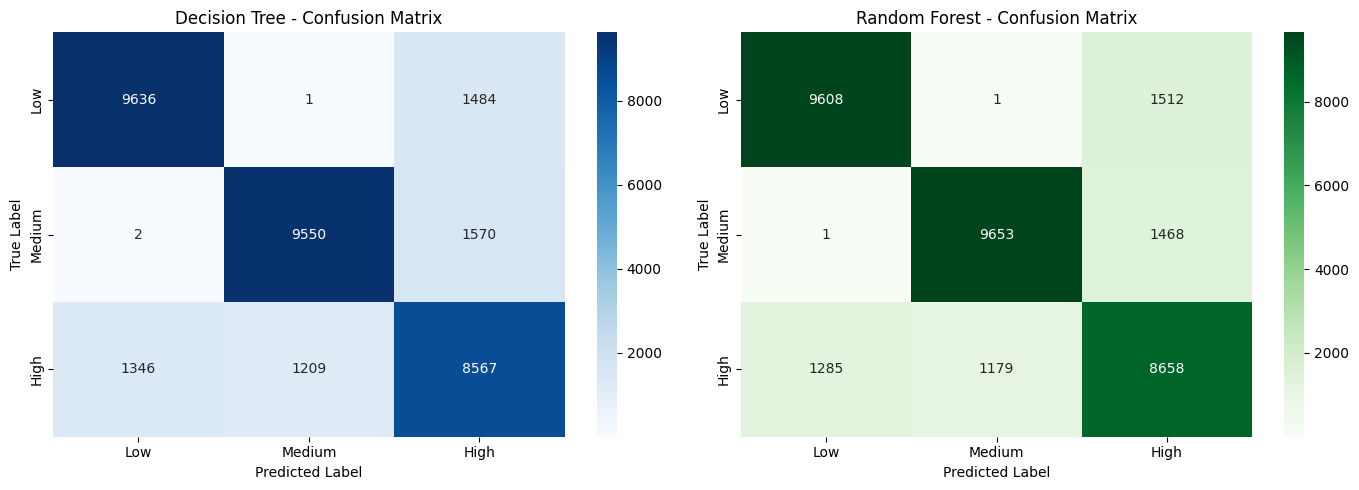

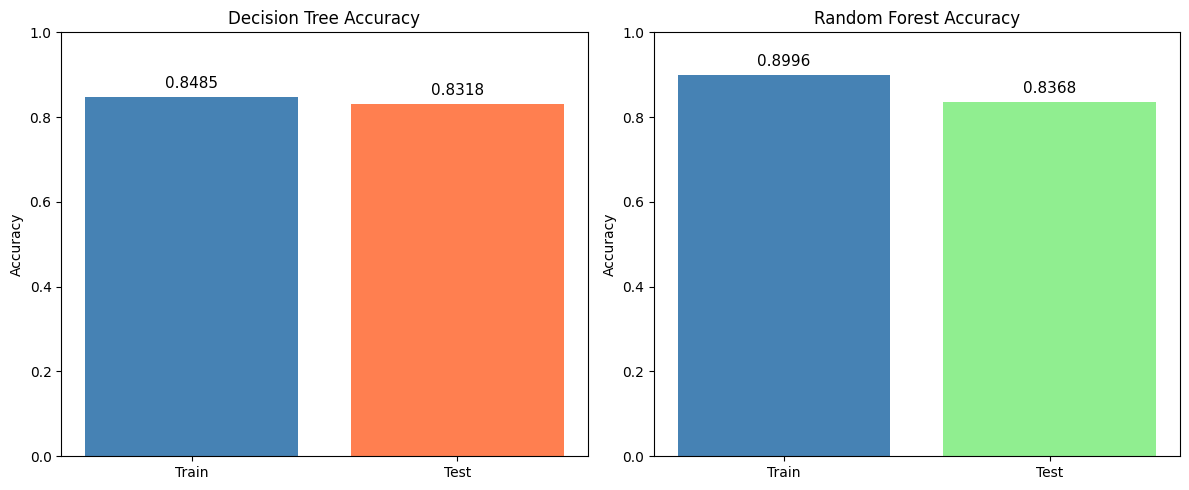


✅ All visualizations complete!


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Confusion Matrices for Both Models (Test Set Only)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_dt_test = confusion_matrix(y_test, y_pred_dt_test)
sns.heatmap(cm_dt_test, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low', 'Medium', 'High'], 
            yticklabels=['Low', 'Medium', 'High'], ax=axes[0])
axes[0].set_title('Decision Tree - Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

cm_rf_test = confusion_matrix(y_test, y_pred_rf_test)
sns.heatmap(cm_rf_test, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Low', 'Medium', 'High'], 
            yticklabels=['Low', 'Medium', 'High'], ax=axes[1])
axes[1].set_title('Random Forest - Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# 2. Accuracy Comparison (Train vs Test)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Decision Tree
dt_train_acc = accuracy_score(y_train, y_pred_dt_train)
dt_test_acc = accuracy_score(y_test, y_pred_dt_test)
axes[0].bar(['Train', 'Test'], [dt_train_acc, dt_test_acc], color=['steelblue', 'coral'])
axes[0].set_title('Decision Tree Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0, 1])
for i, (label, val) in enumerate(zip(['Train', 'Test'], [dt_train_acc, dt_test_acc])):
    axes[0].text(i, val + 0.02, f'{val:.4f}', ha='center', fontsize=11)

# Random Forest
rf_train_acc = accuracy_score(y_train, y_pred_rf_train)
rf_test_acc = accuracy_score(y_test, y_pred_rf_test)
axes[1].bar(['Train', 'Test'], [rf_train_acc, rf_test_acc], color=['steelblue', 'lightgreen'])
axes[1].set_title('Random Forest Accuracy')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0, 1])
for i, (label, val) in enumerate(zip(['Train', 'Test'], [rf_train_acc, rf_test_acc])):
    axes[1].text(i, val + 0.02, f'{val:.4f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print("\n✅ All visualizations complete!")

## Test the model with new data

In [15]:
# Create a test farm data
new_farm = pd.DataFrame({
    'Soil_Type': ['Clay'],
    'Rainfall_mm': [599.8],
    'Temperature_Celsius': [19.90],
    'Fertilizer_Used': [True],
    'Irrigation_Used': [0],
    'Days_to_Harvest': [63]
})

# Encode Soil_Type using the same encoder
new_farm['Soil_Type'] = label_encoders['Soil_Type'].transform(new_farm['Soil_Type'].astype(str))

# Make predictions with both models
dt_pred = model_dt.predict(new_farm)
rf_pred = model_rf.predict(new_farm)

print("PREDICTION FOR NEW FARM")
print(f"Decision Tree Prediction: {dt_pred[0]}")
print(f"Random Forest Prediction: {rf_pred[0]}")

PREDICTION FOR NEW FARM
Decision Tree Prediction: Medium
Random Forest Prediction: Medium
